# تشخیص موجودیت‌های نامدار فارسی با روش‌های کم‌پارامتر

## مقایسه Full Fine-tuning، LoRA و Bottleneck Adapter

در این پروژه مدل `xlm-roberta-base` روی دیتاست فارسی ARMAN برای مسئله تشخیص موجودیت‌های نامدار آموزش داده شده است.

سه روش زیر بررسی و مقایسه شده‌اند:

1. Full Fine-tuning
2. LoRA
3. Bottleneck Adapter

معیارهای اصلی مقایسه شامل Precision، Recall، F1، Accuracy و درصد پارامترهای قابل‌آموزش هستند.

## ۱. آماده‌سازی محیط اجرا

در این بخش کارت گرافیک بررسی می‌شود، کتابخانه‌های موردنیاز نصب می‌شوند و Google Drive برای ذخیره داده‌ها، مدل‌ها و نتایج به محیط Colab متصل می‌شود.

> **نکته اجرایی:** این نوت‌بوک در دو مرحله اجرا شده است.  
> ابتدا Full Fine-tuning و LoRA با `transformers==5.13.0` اجرا شدند.  
> سپس برای اجرای Adapter، نسخه‌های `transformers==4.57.6` و `adapters==1.3.0` نصب و Session ریست شد.  
> بنابراین نباید کل نوت‌بوک بدون توقف با گزینه `Run all` اجرا شود.


In [ ]:
# وارد کردن کتابخانه PyTorch
import torch

# بررسی فعال بودن کارت گرافیک
print("GPU فعال است؟", torch.cuda.is_available())

# نمایش نام کارت گرافیک
if torch.cuda.is_available():
    print("نام GPU:", torch.cuda.get_device_name(0))

GPU فعال است؟ True
نام GPU: Tesla T4


In [ ]:
# نصب کتابخانه‌های موردنیاز پروژه
%pip install -q \
    "transformers==5.13.0" \
    "datasets==5.0.0" \
    "pyarrow==25.0.0" \
    "evaluate==0.4.6" \
    "seqeval==1.2.2" \
    "accelerate==1.14.0" \
    "peft==0.19.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [ ]:
# وارد کردن کتابخانه‌های اصلی پروژه
import torch
import transformers
import datasets
import evaluate
import peft

# نمایش نسخه کتابخانه‌ها
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("peft:", peft.__version__)

print("\nکتابخانه‌ها آماده هستند.")

torch: 2.11.0+cu128
transformers: 5.13.0
datasets: 5.0.0
evaluate: 0.4.6
peft: 0.19.1

کتابخانه‌ها آماده هستند.


In [ ]:
# اتصال Google Drive به Colab
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ساخت مسیرهای اصلی پروژه در Google Drive
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/persian-ner-peft")
OUTPUT_DIR = PROJECT_DIR / "outputs"
FULL_OUTPUT_DIR = OUTPUT_DIR / "full-finetuning"

# ساخت پوشه‌ها
FULL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("پوشه اصلی پروژه:")
print(PROJECT_DIR)

print("\nپوشه ذخیره Full Fine-tuning:")
print(FULL_OUTPUT_DIR)

پوشه اصلی پروژه:
/content/drive/MyDrive/persian-ner-peft

پوشه ذخیره Full Fine-tuning:
/content/drive/MyDrive/persian-ner-peft/outputs/full-finetuning


In [ ]:
# تنظیمات اصلی پروژه
from transformers import set_seed

SEED = 42
MODEL_NAME = "xlm-roberta-base"
DATASET_NAME = "hezarai/arman-ner"

# ثابت کردن بخش‌های تصادفی برای تکرارپذیری نتیجه‌ها
set_seed(SEED)

print("مدل پایه:", MODEL_NAME)
print("دیتاست:", DATASET_NAME)
print("Seed:", SEED)

مدل پایه: xlm-roberta-base
دیتاست: hezarai/arman-ner
Seed: 42


## ۲. بارگذاری و بررسی دیتاست ARMAN

در این پروژه از دیتاست فارسی ARMAN برای تشخیص موجودیت‌های نامدار استفاده شده است.  
هر نمونه شامل دو بخش اصلی است:

- `tokens`: کلمه‌های جمله
- `ner_tags`: برچسب عددی هر کلمه

موجودیت‌های دیتاست شامل شخص، سازمان، مکان، محصول، تأسیسات و رویداد هستند.  
داده‌های آموزشی با `seed=42` به بخش‌های آموزش و اعتبارسنجی تقسیم می‌شوند و مجموعه test بدون تغییر نگه داشته می‌شود.

In [ ]:
# بارگذاری دیتاست ARMAN
from datasets import load_dataset

dataset = load_dataset(DATASET_NAME)

# نمایش تعداد نمونه‌های هر بخش
for split_name in dataset.keys():
    print(split_name, ":", len(dataset[split_name]))

In [ ]:
# گرفتن اولین نمونه از داده‌های آموزشی
first_example = dataset["train"][0]

# نمایش ستون‌های دیتاست
print("ستون‌های دیتاست:")
print(first_example.keys())

# گرفتن نام برچسب‌های NER
label_names = dataset["train"].features["ner_tags"].feature.names

print("\nنام برچسب‌ها:")
print(label_names)

print("\nتعداد برچسب‌ها:")
print(len(label_names))

ستون‌های دیتاست:
dict_keys(['tokens', 'ner_tags'])

نام برچسب‌ها:
['O', 'B-pro', 'I-pro', 'B-pers', 'I-pers', 'B-org', 'I-org', 'B-loc', 'I-loc', 'B-fac', 'I-fac', 'B-event', 'I-event']

تعداد برچسب‌ها:
13


In [ ]:
# ساخت بخش‌های train و validation
from datasets import DatasetDict

# جدا کردن ۱۰ درصد از داده‌های train برای validation
split_data = dataset["train"].train_test_split(
    test_size=0.10,
    seed=SEED
)

# ساخت دیتاست نهایی با سه بخش
dataset = DatasetDict({
    "train": split_data["train"],
    "validation": split_data["test"],
    "test": dataset["test"]
})

# نمایش تعداد نمونه‌های هر بخش
for split_name in dataset.keys():
    print(split_name, ":", len(dataset[split_name]))

## ۳. توکن‌سازی و هماهنگ‌کردن برچسب‌ها

مدل XLM-RoBERTa متن را مستقیماً به‌صورت کلمه دریافت نمی‌کند و ابتدا جمله را به توکن و زیرتوکن تبدیل می‌کند.

از آنجا که ممکن است یک کلمه به چند زیرتوکن تقسیم شود:

- برچسب اصلی فقط به اولین زیرتوکن داده می‌شود.
- سایر زیرتوکن‌های همان کلمه مقدار `-100` می‌گیرند.
- توکن‌های ویژه مانند ابتدا و انتهای جمله نیز مقدار `-100` می‌گیرند.

مقدار `-100` باعث می‌شود این قسمت‌ها هنگام محاسبه خطای آموزش نادیده گرفته شوند. حداکثر طول ورودی نیز ۲۵۶ توکن در نظر گرفته شده است.

In [ ]:
# وارد کردن Tokenizer
from transformers import AutoTokenizer

# بارگذاری Tokenizer مدل XLM-RoBERTa
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer آماده شد.")
print("نوع Tokenizer:", type(tokenizer).__name__)
print("حداکثر طول ورودی:", tokenizer.model_max_length)

#این بخش متن را به توکن‌های قابل‌فهم برای مدل تبدیل می‌کند.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer آماده شد.
نوع Tokenizer: XLMRobertaTokenizerFast
حداکثر طول ورودی: 512


In [ ]:
# پیدا کردن اولین جمله‌ای که موجودیت نامدار دارد
for example in dataset["train"]:
    if any(tag != 0 for tag in example["ner_tags"]):
        sample = example
        break

# توکن‌سازی جمله
encoded_sample = tokenizer(
    sample["tokens"],
    is_split_into_words=True,
    truncation=True
)

# تبدیل شماره توکن‌ها به شکل قابل خواندن
model_tokens = tokenizer.convert_ids_to_tokens(
    encoded_sample["input_ids"]
)

# مشخص کردن ارتباط هر توکن با کلمه اصلی
word_ids = encoded_sample.word_ids()

# نمایش ۲۰ توکن اول
for token, word_id in list(zip(model_tokens, word_ids))[:20]:
    print(token, "->", word_id)

<s> -> None
▁گرو -> 0
گان -> 0
گیری -> 0
▁روز -> 1
▁جمعه -> 2
▁با -> 3
▁هجوم -> 4
▁افراد -> 5
▁مسلح -> 6
▁به -> 7
▁سفارت -> 8
خانه -> 8
▁میان -> 9
مار -> 9
▁در -> 10
▁بانک -> 11
وک -> 11
▁آغاز -> 12
▁شد -> 13


In [ ]:
# برچسب‌های اصلی جمله
original_labels = sample["ner_tags"]

# لیست برچسب‌های جدید
aligned_labels = []

# شماره کلمه قبلی
previous_word_id = None

# بررسی زیرتوکن‌ها
for word_id in word_ids:

    # توکن‌های ویژه مثل <s> نادیده گرفته می‌شوند
    if word_id is None:
        aligned_labels.append(-100)

    # اولین بخش هر کلمه، برچسب اصلی را می‌گیرد
    elif word_id != previous_word_id:
        aligned_labels.append(original_labels[word_id])

    # بخش‌های بعدی همان کلمه نادیده گرفته می‌شوند
    else:
        aligned_labels.append(-100)

    previous_word_id = word_id


# نمایش نتیجه
for token, label_id in list(zip(model_tokens, aligned_labels))[:20]:

    if label_id == -100:
        label = "نادیده گرفته می‌شود"
    else:
        label = label_names[label_id]

    print(token, "->", label)




In [ ]:
# حداکثر طول ورودی مدل
MAX_LENGTH = 256


# توکن‌سازی جمله‌ها و هماهنگ کردن برچسب‌ها با زیرتوکن‌ها
def prepare_data(examples):

    # تبدیل کلمه‌ها به توکن‌های قابل فهم برای مدل
    tokenized_data = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    # برچسب‌های نهایی همه جمله‌ها
    all_labels = []

    # بررسی جمله‌ها یکی‌یکی
    for i in range(len(examples["tokens"])):

        word_ids = tokenized_data.word_ids(batch_index=i)
        original_labels = examples["ner_tags"][i]

        new_labels = []
        previous_word_id = None

        # هماهنگ کردن برچسب هر کلمه با زیرتوکن‌های آن
        for word_id in word_ids:

            if word_id is None:
                new_labels.append(-100)

            elif word_id != previous_word_id:
                new_labels.append(original_labels[word_id])

            else:
                new_labels.append(-100)

            previous_word_id = word_id

        all_labels.append(new_labels)

    # اضافه کردن برچسب‌ها به داده‌های توکن‌شده
    tokenized_data["labels"] = all_labels

    return tokenized_data


#این تابع متن را توکن‌سازی می‌کند و برچسب هر کلمه را فقط به اولین زیرتوکن آن می‌دهد.
# توکن‌های ویژه و زیرتوکن‌های اضافی با مقدار -100 نادیده گرفته می‌شوند.

In [ ]:
# اجرای تابع آماده‌سازی روی همه بخش‌های دیتاست
tokenized_dataset = dataset.map(
    prepare_data,
    batched=True,
    remove_columns=["tokens", "ner_tags"]
)

# نمایش ساختار دیتاست آماده‌شده
print(tokenized_dataset)

In [ ]:
# گرفتن اولین نمونه از داده‌های آماده‌شده
first_tokenized_example = tokenized_dataset["train"][0]

# نمایش ستون‌های نمونه
print("ستون‌های نمونه:")
print(first_tokenized_example.keys())

# بررسی برابر بودن تعداد توکن‌ها و برچسب‌ها
print("\nتعداد توکن‌ها:")
print(len(first_tokenized_example["input_ids"]))

print("\nتعداد برچسب‌ها:")
print(len(first_tokenized_example["labels"]))

ستون‌های نمونه:
dict_keys(['input_ids', 'attention_mask', 'labels'])

تعداد توکن‌ها:
53

تعداد برچسب‌ها:
53


In [ ]:
# ساخت جدول‌های تبدیل بین شماره برچسب‌ها و نام آن‌ها
# این جدول‌ها کمک می‌کنند خروجی عددی مدل به برچسب‌های قابل‌خواندن NER تبدیل شود

# تعداد برچسب‌های دیتاست
num_labels = len(label_names)

# دیکشنری تبدیل شماره به نام برچسب
id2label = {}

# دیکشنری تبدیل نام برچسب به شماره
label2id = {}

# ساخت دیکشنری‌ها
for label_id in range(num_labels):
    label_name = label_names[label_id]

    id2label[label_id] = label_name
    label2id[label_name] = label_id

# نمایش نتیجه
print("تعداد برچسب‌ها:", num_labels)
print("\nشماره به نام:")
print(id2label)

print("\nنام به شماره:")
print(label2id)


تعداد برچسب‌ها: 13

شماره به نام:
{0: 'O', 1: 'B-pro', 2: 'I-pro', 3: 'B-pers', 4: 'I-pers', 5: 'B-org', 6: 'I-org', 7: 'B-loc', 8: 'I-loc', 9: 'B-fac', 10: 'I-fac', 11: 'B-event', 12: 'I-event'}

نام به شماره:
{'O': 0, 'B-pro': 1, 'I-pro': 2, 'B-pers': 3, 'I-pers': 4, 'B-org': 5, 'I-org': 6, 'B-loc': 7, 'I-loc': 8, 'B-fac': 9, 'I-fac': 10, 'B-event': 11, 'I-event': 12}


In [ ]:
# آماده‌کردن جمله‌های با طول متفاوت برای ورود هم‌زمان به مدل
# این ابزار در هر batch، جمله‌ها و برچسب‌ها را تا یک طول برابر padding می‌کند

from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

print("Data Collator آماده شد.")

Data Collator آماده شد.


## ۴. معیارهای ارزیابی

برای ارزیابی مدل‌های تشخیص موجودیت نامدار از کتابخانه `seqeval` استفاده می‌شود.

معیارهای اصلی عبارت‌اند از:

- **Precision:** چه مقدار از موجودیت‌های پیش‌بینی‌شده درست بوده‌اند.
- **Recall:** چه مقدار از موجودیت‌های واقعی توسط مدل پیدا شده‌اند.
- **F1:** میانگین متوازن Precision و Recall و معیار اصلی مقایسه مدل‌ها.
- **Accuracy:** درصد برچسب‌های درست در سطح توکن‌ها.

بهترین checkpoint هر روش بر اساس مقدار F1 روی مجموعه validation انتخاب می‌شود. مجموعه test فقط برای ارزیابی نهایی استفاده می‌شود.

In [ ]:
# بارگذاری معیارهای ارزیابی مدل برای مسئله NER
# این معیارها شامل Precision، Recall، F1 و Accuracy هستند

import evaluate

metric = evaluate.load("seqeval")

print("معیار ارزیابی seqeval آماده شد.")

معیار ارزیابی seqeval آماده شد.


In [ ]:
# محاسبه معیارهای ارزیابی مدل
# این تابع پیش‌بینی‌های عددی مدل را به نام برچسب‌ها تبدیل می‌کند
# سپس Precision، Recall، F1 و Accuracy را محاسبه می‌کند

import numpy as np

def compute_metrics(eval_result):

    # خروجی مدل و برچسب‌های واقعی
    predictions = eval_result.predictions
    labels = eval_result.label_ids

    # انتخاب برچسبی که بیشترین امتیاز را دارد
    predicted_ids = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    # بررسی جمله‌ها
    for prediction, label in zip(predicted_ids, labels):

        sentence_predictions = []
        sentence_labels = []

        # بررسی توکن‌های هر جمله
        for predicted_id, label_id in zip(prediction, label):

            # حذف توکن‌هایی که با -100 مشخص شده‌اند
            if label_id != -100:
                sentence_predictions.append(
                    id2label[int(predicted_id)]
                )

                sentence_labels.append(
                    id2label[int(label_id)]
                )

        true_predictions.append(sentence_predictions)
        true_labels.append(sentence_labels)

    # محاسبه معیارها
    results = metric.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

print("تابع ارزیابی ساخته شد.")

تابع ارزیابی ساخته شد.


In [ ]:
# ذخیره دیتاست توکنایزشده در Google Drive
# با این کار لازم نیست بعداً دوباره کل دیتاست را آماده کنیم

TOKENIZED_DATA_DIR = PROJECT_DIR / "data" / "tokenized_dataset_final"

tokenized_dataset.save_to_disk(
    str(TOKENIZED_DATA_DIR)
)

print("دیتاست ذخیره شد:")
print(TOKENIZED_DATA_DIR)

## ۵. آموزش کامل مدل (Full Fine-tuning)

در این روش تمام پارامترهای مدل XLM-RoBERTa قابل‌آموزش هستند.

مدل به‌مدت ۳ دوره روی داده‌های آموزشی آموزش داده می‌شود. در پایان هر دوره، عملکرد مدل روی مجموعه validation محاسبه شده و بهترین checkpoint بر اساس مقدار F1 انتخاب می‌شود.

این روش معمولاً بیشترین دقت را دارد، اما حافظه و هزینه محاسباتی بیشتری مصرف می‌کند.

In [ ]:
# بارگذاری مدل XLM-RoBERTa برای مسئله تشخیص موجودیت‌های نامدار

from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# انتقال مدل به GPU
model = model.to("cuda")

print("مدل آماده شد.")
print("دستگاه مدل:", next(model.parameters()).device)
print("تعداد برچسب‌های خروجی:", model.config.num_labels)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


مدل آماده شد.
دستگاه مدل: cuda:0
تعداد برچسب‌های خروجی: 13


In [ ]:
# شمردن تعداد کل پارامترهای مدل
# و تعداد پارامترهایی که در Full Fine-tuning آموزش می‌بینند

total_params = 0
trainable_params = 0

for parameter in model.parameters():

    total_params += parameter.numel()

    if parameter.requires_grad:
        trainable_params += parameter.numel()

# محاسبه درصد پارامترهای قابل آموزش
trainable_percent = 100 * trainable_params / total_params

print("تعداد کل پارامترها:", total_params)
print("تعداد پارامترهای قابل آموزش:", trainable_params)
print("درصد پارامترهای قابل آموزش:", round(trainable_percent, 2), "%")

تعداد کل پارامترها: 277463053
تعداد پارامترهای قابل آموزش: 277463053
درصد پارامترهای قابل آموزش: 100.0 %


In [ ]:
# تنظیمات آموزش اصلی Full Fine-tuning
# مدل در پایان هر دوره ارزیابی و داخل Google Drive ذخیره می‌شود

from transformers import TrainingArguments

full_training_args = TrainingArguments(
    output_dir=str(FULL_OUTPUT_DIR),

    # مدل سه بار کل داده‌های آموزشی را می‌بیند
    num_train_epochs=3,

    # اندازه batch متناسب با حافظه T4
    per_device_train_batch_size=1,
    per_device_eval_batch_size=2,

    # جمع کردن گرادیان ۸ مرحله
    gradient_accumulation_steps=8,

    # سرعت یادگیری
    learning_rate=2e-5,
    weight_decay=0.01,

    # ارزیابی و ذخیره در پایان هر epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # انتخاب بهترین مدل بر اساس F1
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # نگه‌داشتن حداکثر دو checkpoint
    save_total_limit=2,

    # کاهش مصرف حافظه GPU
    fp16=True,
    gradient_checkpointing=True,

    # نمایش گزارش هر 100 مرحله
    logging_steps=100,

    # غیرفعال کردن گزارش‌دهنده‌های اضافی
    report_to="none",

    seed=42
)

print("تنظیمات آموزش Full Fine-tuning آماده شد.")
print("مسیر ذخیره:", FULL_OUTPUT_DIR)

تنظیمات آموزش Full Fine-tuning آماده شد.
مسیر ذخیره: /content/drive/MyDrive/persian-ner-peft/outputs/full-finetuning


In [ ]:
# ساخت ابزار اصلی آموزش Full Fine-tuning
# این بخش مدل، داده‌ها و تنظیمات آموزش را به هم متصل می‌کند

from transformers import Trainer

full_trainer = Trainer(
    model=model,
    args=full_training_args,

    # داده‌های آموزش و اعتبارسنجی
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    # آماده‌سازی batchها
    data_collator=data_collator,

    # محاسبه معیارهای ارزیابی
    compute_metrics=compute_metrics,

    # Tokenizer پروژه
    processing_class=tokenizer
)

print("Trainer ساخته شد.")
print("تعداد داده‌های آموزش:", len(full_trainer.train_dataset))
print("تعداد داده‌های اعتبارسنجی:", len(full_trainer.eval_dataset))

Trainer ساخته شد.
تعداد داده‌های آموزش: 18435
تعداد داده‌های اعتبارسنجی: 2049


In [ ]:
# شروع آموزش Full Fine-tuning
# در صورت وجود checkpoint، آموزش از آخرین مرحله ذخیره‌شده ادامه پیدا می‌کند

from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = get_last_checkpoint(
    str(FULL_OUTPUT_DIR)
)

if last_checkpoint is not None:
    print("ادامه آموزش از:")
    print(last_checkpoint)

    full_train_result = full_trainer.train(
        resume_from_checkpoint=last_checkpoint
    )

else:
    print("آموزش از ابتدا شروع می‌شود.")

    full_train_result = full_trainer.train()

آموزش از ابتدا شروع می‌شود.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.438951,0.057732,0.816487,0.858762,0.837091,0.982897
2,0.268195,0.037778,0.880820,0.921569,0.900734,0.989471
3,0.149442,0.030288,0.913661,0.946691,0.929883,0.992407


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# بررسی checkpointهای ذخیره‌شده در Google Drive

from google.colab import drive
from pathlib import Path
from transformers.trainer_utils import get_last_checkpoint

# اتصال Drive
drive.mount("/content/drive")

# مسیر خروجی آموزش
FULL_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/persian-ner-peft/outputs/full-finetuning"
)

# پیدا کردن آخرین checkpoint
last_checkpoint = get_last_checkpoint(
    str(FULL_OUTPUT_DIR)
)

print("آخرین checkpoint:")
print(last_checkpoint)

print("\ncheckpointهای موجود:")
for checkpoint in sorted(FULL_OUTPUT_DIR.glob("checkpoint-*")):
    print(checkpoint.name)

Mounted at /content/drive
آخرین checkpoint:
/content/drive/MyDrive/persian-ner-peft/outputs/full-finetuning/checkpoint-6915

checkpointهای موجود:
checkpoint-4610
checkpoint-6915


In [ ]:
# خواندن نتیجه‌های ذخیره‌شده آموزش Full Fine-tuning

import json

trainer_state_path = Path(last_checkpoint) / "trainer_state.json"

with open(trainer_state_path, "r", encoding="utf-8") as file:
    trainer_state = json.load(file)

print("بهترین checkpoint:")
print(trainer_state["best_model_checkpoint"])

print("\nبهترین مقدار F1:")
print(trainer_state["best_metric"])

print("\nنتیجه هر epoch:")

for result in trainer_state["log_history"]:

    if "eval_f1" in result:
        print(
            "Epoch:", result["epoch"],
            "| Precision:", round(result["eval_precision"], 6),
            "| Recall:", round(result["eval_recall"], 6),
            "| F1:", round(result["eval_f1"], 6),
            "| Accuracy:", round(result["eval_accuracy"], 6)
        )

بهترین checkpoint:
/content/drive/MyDrive/persian-ner-peft/outputs/full-finetuning/checkpoint-6915

بهترین مقدار F1:
0.9298826361721335

نتیجه هر epoch:
Epoch: 1.0 | Precision: 0.816487 | Recall: 0.858762 | F1: 0.837091 | Accuracy: 0.982897
Epoch: 2.0 | Precision: 0.88082 | Recall: 0.921569 | F1: 0.900734 | Accuracy: 0.989471
Epoch: 3.0 | Precision: 0.913661 | Recall: 0.946691 | F1: 0.929883 | Accuracy: 0.992407


In [ ]:
# ذخیره نتیجه‌های Full Fine-tuning داخل Google Drive

import json
from pathlib import Path

# مسیر اصلی پروژه
PROJECT_DIR = Path("/content/drive/MyDrive/persian-ner-peft")

# نتیجه‌های مدل
full_results = {
    "method": "Full Fine-tuning",
    "model": "xlm-roberta-base",
    "total_parameters": 277463053,
    "trainable_parameters": 277463053,
    "trainable_percent": 100.0,
    "best_checkpoint": trainer_state["best_model_checkpoint"],
    "best_epoch": 3,
    "precision": 0.913661,
    "recall": 0.946691,
    "f1": 0.929883,
    "accuracy": 0.992407
}

# مسیر فایل خروجی
results_file = PROJECT_DIR / "outputs" / "full_finetuning_results.json"

# ذخیره نتیجه‌ها
with open(results_file, "w", encoding="utf-8") as file:
    json.dump(
        full_results,
        file,
        ensure_ascii=False,
        indent=4
    )

print("نتیجه‌ها ذخیره شدند:")
print(results_file)

نتیجه‌ها ذخیره شدند:
/content/drive/MyDrive/persian-ner-peft/outputs/full_finetuning_results.json


In [ ]:
# بررسی فعال بودن GPU برای شروع آموزش LoRA

import torch

print("GPU فعال است؟", torch.cuda.is_available())

if torch.cuda.is_available():
    print("نام GPU:", torch.cuda.get_device_name(0))

GPU فعال است؟ True
نام GPU: Tesla T4


In [ ]:
# بازیابی دیتاست آماده‌شده و نام برچسب‌ها بعد از تغییر Runtime

from datasets import load_from_disk

# مسیر دیتاست ذخیره‌شده
TOKENIZED_DATA_DIR = PROJECT_DIR / "data" / "tokenized_dataset_final"

# بارگذاری دیتاست آماده‌شده از Google Drive
tokenized_dataset = load_from_disk(
    str(TOKENIZED_DATA_DIR)
)

# نام برچسب‌های دیتاست ARMAN
label_names = [
    "O",
    "B-pro", "I-pro",
    "B-pers", "I-pers",
    "B-org", "I-org",
    "B-loc", "I-loc",
    "B-fac", "I-fac",
    "B-event", "I-event"
]

print("دیتاست آماده شد.")
print(tokenized_dataset)
print("تعداد برچسب‌ها:", len(label_names))

دیتاست آماده شد.
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20484
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2561
    })
})
تعداد برچسب‌ها: 13


## ۶. آموزش  با LoRA

در روش LoRA وزن‌های اصلی مدل ثابت می‌مانند و فقط ماتریس‌های کوچک جدیدی آموزش می‌بینند. این ماتریس‌ها به لایه‌های `query` و `value` در بخش Attention اضافه شده‌اند.

تنظیمات اصلی LoRA:

- رتبه ماتریس‌ها: `r = 8`
- ضریب مقیاس: `lora_alpha = 16`
- Dropout: `0.1`
- لایه‌های هدف: `query` و `value`
- تعداد دوره‌های آموزش: ۳
- Batch مؤثر: ۸

لایه نهایی `classifier` نیز آموزش داده می‌شود؛ زیرا باید ۱۳ برچسب دیتاست ARMAN را پیش‌بینی کند.

در این روش فقط حدود `0.1098%` از کل پارامترهای مدل قابل‌آموزش هستند.

In [ ]:
# دانلود و ذخیره مدل پایه در Google Drive
# با ذخیره مدل در Drive، بعد از قطع شدن Colab دوباره دانلود نمی‌شود

import os
from huggingface_hub import snapshot_download

# غیرفعال کردن روش دانلودی که قبلاً گیر می‌کرد
os.environ["HF_HUB_DISABLE_XET"] = "1"

# مسیر دائمی ذخیره مدل
MODEL_DIR = PROJECT_DIR / "models" / "xlm-roberta-base"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# دانلود فایل‌های موردنیاز مدل
snapshot_download(
    repo_id=MODEL_NAME,
    local_dir=str(MODEL_DIR),
    allow_patterns=[
        "config.json",
        "model.safetensors"
    ],
    max_workers=1
)

print("مدل پایه ذخیره شد:")
print(MODEL_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

مدل پایه ذخیره شد:
/content/drive/MyDrive/persian-ner-peft/models/xlm-roberta-base


In [ ]:
# ساخت مدل LoRA از مدل پایه ذخیره‌شده در Google Drive
# فقط پارامترهای LoRA و لایه نهایی NER قابل آموزش خواهند بود

from transformers import AutoModelForTokenClassification
from peft import LoraConfig, TaskType, get_peft_model

# بارگذاری مدل پایه از Drive
base_model = AutoModelForTokenClassification.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# تنظیمات LoRA
lora_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    modules_to_save=["classifier"],
    bias="none"
)

# اضافه کردن LoRA به مدل پایه
lora_model = get_peft_model(
    base_model,
    lora_config
)

# انتقال مدل به GPU
lora_model = lora_model.to("cuda")

# نمایش تعداد پارامترهای قابل آموزش
lora_model.print_trainable_parameters()


# ساخت مدل LoRA از روی XLM-RoBERTa
# وزن‌های اصلی مدل ثابت می‌مانند و فقط پارامترهای کوچک LoRA
# همراه با لایه نهایی classifier برای مسئله NER آموزش می‌بینند
# به همین دلیل فقط حدود 0.11 درصد از پارامترهای مدل قابل آموزش هستند

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: /content/drive/MyDrive/persian-ner-peft/models/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 304,909 || all params: 277,767,962 || trainable%: 0.1098


In [ ]:
# تنظیمات آموزش LoRA
# نتیجه‌ها و checkpointها داخل Google Drive ذخیره می‌شوند

from transformers import TrainingArguments

# مسیر ذخیره خروجی‌های LoRA
LORA_OUTPUT_DIR = PROJECT_DIR / "outputs" / "lora"
LORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

lora_training_args = TrainingArguments(
    output_dir=str(LORA_OUTPUT_DIR),

    # مدل سه بار کل داده‌های آموزشی را می‌بیند
    num_train_epochs=3,

    # اندازه batch مؤثر برابر ۸ است
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,

    # سرعت یادگیری LoRA
    learning_rate=1e-4,
    weight_decay=0.01,

    # ارزیابی و ذخیره در پایان هر epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # انتخاب بهترین مدل بر اساس F1
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # نگه‌داشتن حداکثر دو checkpoint
    save_total_limit=2,

    # کاهش مصرف حافظه و افزایش سرعت روی T4
    fp16=True,

    # نمایش گزارش هر 100 مرحله
    logging_steps=100,

    # غیرفعال کردن گزارش‌دهنده‌های اضافی
    report_to="none",

    seed=42
)

print("تنظیمات آموزش LoRA آماده شد.")
print("مسیر ذخیره:", LORA_OUTPUT_DIR)

تنظیمات آموزش LoRA آماده شد.
مسیر ذخیره: /content/drive/MyDrive/persian-ner-peft/outputs/lora


In [ ]:
# ساخت Trainer برای آموزش مدل LoRA
# این بخش مدل، داده‌ها و تنظیمات آموزش را به هم وصل می‌کند

from transformers import Trainer

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,

    # داده‌های آموزش و اعتبارسنجی
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    # آماده‌سازی batchها
    data_collator=data_collator,

    # محاسبه معیارهای ارزیابی
    compute_metrics=compute_metrics,

    # Tokenizer پروژه
    processing_class=tokenizer
)

print("Trainer مدل LoRA ساخته شد.")
print("تعداد داده‌های آموزش:", len(lora_trainer.train_dataset))
print("تعداد داده‌های اعتبارسنجی:", len(lora_trainer.eval_dataset))

Trainer مدل LoRA ساخته شد.
تعداد داده‌های آموزش: 18435
تعداد داده‌های اعتبارسنجی: 2049


In [ ]:
# شروع آموزش مدل LoRA
# زمان آموزش و بیشترین حافظه مصرف‌شده GPU نیز ثبت می‌شود
# تا بعداً با Full Fine-tuning مقایسه شوند

import time
import torch

# پاک‌سازی حافظه‌های اضافی GPU قبل از شروع
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start_time = time.time()

# شروع آموزش
lora_train_result = lora_trainer.train()

# محاسبه زمان و بیشترین حافظه مصرف‌شده
lora_training_time = time.time() - start_time
lora_peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

print("\nآموزش LoRA تمام شد.")
print(f"زمان آموزش: {lora_training_time / 60:.2f} دقیقه")
print(f"بیشترین حافظه GPU: {lora_peak_memory_gb:.2f} گیگابایت")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.201112,0.107401,0.660874,0.745711,0.700734,0.966190
2,0.204031,0.092323,0.692498,0.772059,0.730117,0.970573
3,0.183688,0.087360,0.719239,0.787990,0.752047,0.972977



آموزش LoRA تمام شد.
زمان آموزش: 12.55 دقیقه
بیشترین حافظه GPU: 1.55 گیگابایت


In [ ]:
# ذخیره بهترین مدل LoRA و نتایج نهایی آن
# چون load_best_model_at_end فعال بود، مدل فعلی بهترین checkpoint است

import json

# مسیر ذخیره بهترین مدل
BEST_LORA_DIR = LORA_OUTPUT_DIR / "best_model"
BEST_LORA_DIR.mkdir(parents=True, exist_ok=True)

# ذخیره وزن‌های LoRA و tokenizer
lora_trainer.save_model(str(BEST_LORA_DIR))
tokenizer.save_pretrained(str(BEST_LORA_DIR))

# ارزیابی نهایی بهترین مدل روی validation
lora_validation_results = lora_trainer.evaluate(
    tokenized_dataset["validation"]
)

# محاسبه تعداد پارامترها
trainable_params = sum(
    parameter.numel()
    for parameter in lora_model.parameters()
    if parameter.requires_grad
)

all_params = sum(
    parameter.numel()
    for parameter in lora_model.parameters()
)

# آماده‌سازی نتایج برای ذخیره
lora_results = {
    "method": "LoRA",
    "base_model": MODEL_NAME,
    "best_checkpoint": lora_trainer.state.best_model_checkpoint,
    "best_validation_f1": lora_trainer.state.best_metric,
    "validation_results": lora_validation_results,
    "training_time_minutes": lora_training_time / 60,
    "peak_gpu_memory_gb": lora_peak_memory_gb,
    "trainable_params": trainable_params,
    "all_params": all_params,
    "trainable_percentage": (trainable_params / all_params) * 100
}

# مسیر فایل نتایج
LORA_RESULTS_PATH = OUTPUT_DIR / "lora_results.json"

with open(LORA_RESULTS_PATH, "w", encoding="utf-8") as file:
    json.dump(
        lora_results,
        file,
        ensure_ascii=False,
        indent=4
    )

print("بهترین مدل LoRA ذخیره شد:")
print(BEST_LORA_DIR)

print("\nنتایج LoRA ذخیره شد:")
print(LORA_RESULTS_PATH)

print("\nبهترین checkpoint:")
print(lora_trainer.state.best_model_checkpoint)

print("\nF1 نهایی:")
print(lora_validation_results["eval_f1"])

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.183688,0.087360,3,0.719239,0.787990,0.752047,0.972977


بهترین مدل LoRA ذخیره شد:
/content/drive/MyDrive/persian-ner-peft/outputs/lora/best_model

نتایج LoRA ذخیره شد:
/content/drive/MyDrive/persian-ner-peft/outputs/lora_results.json

بهترین checkpoint:
/content/drive/MyDrive/persian-ner-peft/outputs/lora/checkpoint-6915

F1 نهایی:
0.752046783625731


## ۷. آموزش با Bottleneck Adapter

در این روش، ماژول‌های کوچک Adapter داخل لایه‌های مدل پایه قرار می‌گیرند. وزن‌های اصلی XLM-RoBERTa ثابت می‌مانند و فقط Adapter و لایه خروجی NER آموزش می‌بینند.

تنظیمات اصلی:

- نوع Adapter: `seq_bn`
- تعداد دوره‌های آموزش: ۳
- Batch مؤثر: ۸
- نرخ یادگیری: `1e-4`
- درصد پارامترهای قابل‌آموزش: حدود `0.6243%`

برای استفاده از کتابخانه Adapter، نسخه سازگار `transformers==4.57.6` و `adapters==1.3.0` نصب شد و سپس Session ریست شد.

In [ ]:
# نصب کتابخانه Adapter و نسخه سازگار Transformers

%pip install -q \
    "adapters==1.3.0" \
    "transformers==4.57.6"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
# بررسی نسخه کتابخانه‌ها و وضعیت GPU پس از Restart Session

from importlib.metadata import version
import torch
import transformers
import adapters

print("torch:", version("torch"))
print("transformers:", version("transformers"))
print("adapters:", version("adapters"))
print("huggingface-hub:", version("huggingface-hub"))

print("\nGPU فعال است؟", torch.cuda.is_available())

if torch.cuda.is_available():
    print("نام GPU:", torch.cuda.get_device_name(0))

print("\nکتابخانه Adapter بدون خطا آماده است.")

torch: 2.11.0+cu128
transformers: 4.57.6
adapters: 1.3.0
huggingface-hub: 0.36.2

GPU فعال است؟ True
نام GPU: Tesla T4

کتابخانه Adapter بدون خطا آماده است.


In [ ]:
# بازیابی اطلاعات ضروری پس از Restart Session

from pathlib import Path
from google.colab import drive
from datasets import load_from_disk
from transformers import AutoTokenizer, DataCollatorForTokenClassification

drive.mount("/content/drive")

# مسیرهای پروژه
MODEL_NAME = "xlm-roberta-base"

PROJECT_DIR = Path("/content/drive/MyDrive/persian-ner-peft")
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models" / "xlm-roberta-base"

# بازیابی دیتاست نهایی
TOKENIZED_DATA_DIR = (
    PROJECT_DIR / "data" / "tokenized_dataset_final"
)

tokenized_dataset = load_from_disk(
    str(TOKENIZED_DATA_DIR)
)

# بازیابی Tokenizer ذخیره‌شده
TOKENIZER_DIR = OUTPUT_DIR / "lora" / "best_model"

tokenizer = AutoTokenizer.from_pretrained(
    str(TOKENIZER_DIR),
    local_files_only=True,
    use_fast=True
)

# نام برچسب‌ها
label_names = [
    "O",
    "B-pro", "I-pro",
    "B-pers", "I-pers",
    "B-org", "I-org",
    "B-loc", "I-loc",
    "B-fac", "I-fac",
    "B-event", "I-event"
]

num_labels = len(label_names)

id2label = dict(enumerate(label_names))
label2id = {
    label: index
    for index, label in enumerate(label_names)
}

# آماده‌سازی batchها
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

print(tokenized_dataset)
print("Tokenizer و برچسب‌ها بازیابی شدند.")
print("تعداد برچسب‌ها:", num_labels)

In [ ]:
# بازیابی معیارهای ارزیابی پس از Restart Session

import numpy as np
import evaluate

metric = evaluate.load("seqeval")

def compute_metrics(result):
    predictions, labels = result
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for prediction_row, label_row in zip(predictions, labels):
        predicted_tags = []
        real_tags = []

        for prediction, label in zip(prediction_row, label_row):
            # مقادیر -100 در ارزیابی نادیده گرفته می‌شوند
            if label != -100:
                predicted_tags.append(label_names[prediction])
                real_tags.append(label_names[label])

        true_predictions.append(predicted_tags)
        true_labels.append(real_tags)

    scores = metric.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": scores["overall_precision"],
        "recall": scores["overall_recall"],
        "f1": scores["overall_f1"],
        "accuracy": scores["overall_accuracy"]
    }

print("معیارهای ارزیابی آماده شدند.")

In [ ]:
# مسیر ذخیره خروجی‌های Adapter

ADAPTER_OUTPUT_DIR = (
    OUTPUT_DIR / "adapter"
)

ADAPTER_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("مسیر خروجی Adapter:")
print(ADAPTER_OUTPUT_DIR)

# مسیر مدل پایه ذخیره‌شده در Google Drive
MODEL_DIR = PROJECT_DIR / "models" / "xlm-roberta-base"

print("مسیر مدل پایه:", MODEL_DIR)
print("مدل موجود است؟", MODEL_DIR.exists())

مسیر خروجی Adapter:
/content/drive/MyDrive/persian-ner-peft/outputs/adapter
مسیر مدل پایه: /content/drive/MyDrive/persian-ner-peft/models/xlm-roberta-base
مدل موجود است؟ True


In [ ]:
# ساخت مدل Bottleneck Adapter برای تشخیص موجودیت‌های نامدار
# وزن‌های اصلی XLM-RoBERTa ثابت می‌مانند و فقط Adapter
# همراه با لایه خروجی NER آموزش داده می‌شود

import torch
from adapters import AutoAdapterModel

# نام مشترک Adapter و لایه خروجی
ADAPTER_NAME = "arman_ner"

# بارگذاری مدل پایه از Google Drive
adapter_model = AutoAdapterModel.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True
)

# اضافه کردن Bottleneck Adapter
adapter_model.add_adapter(
    ADAPTER_NAME,
    config="seq_bn"
)

# اضافه کردن لایه خروجی مخصوص Token Classification
adapter_model.add_tagging_head(
    ADAPTER_NAME,
    num_labels=num_labels,
    id2label=id2label
)

# ثابت کردن مدل پایه و فعال‌کردن آموزش Adapter
adapter_model.train_adapter(ADAPTER_NAME)
adapter_model.set_active_adapters(ADAPTER_NAME)

# انتقال مدل به GPU
adapter_model = adapter_model.to("cuda")

# شمارش پارامترها
trainable_params = sum(
    parameter.numel()
    for parameter in adapter_model.parameters()
    if parameter.requires_grad
)

all_params = sum(
    parameter.numel()
    for parameter in adapter_model.parameters()
)

trainable_percentage = (
    trainable_params / all_params
) * 100

print("مدل Adapter آماده شد.")
print("پارامترهای قابل آموزش:", f"{trainable_params:,}")
print("کل پارامترها:", f"{all_params:,}")
print("درصد قابل آموزش:", f"{trainable_percentage:.4f}%")
print("Adapter فعال:", adapter_model.active_adapters)

Some weights of XLMRobertaAdapterModel were not initialized from the model checkpoint at /content/drive/MyDrive/persian-ner-peft/models/xlm-roberta-base and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


مدل Adapter آماده شد.
پارامترهای قابل آموزش: 1,746,655
کل پارامترها: 279,790,303
درصد قابل آموزش: 0.6243%
Adapter فعال: Stack[arman_ner]


In [ ]:
# تنظیمات آموزش Bottleneck Adapter
# تعداد epoch و batch مؤثر با LoRA یکسان نگه داشته می‌شود

from transformers import TrainingArguments

adapter_training_args = TrainingArguments(
    output_dir=str(ADAPTER_OUTPUT_DIR),

    # سه بار مشاهده کامل داده‌های آموزشی
    num_train_epochs=3,

    # batch مؤثر: 4 × 2 = 8
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,

    # نرخ یادگیری مناسب برای Adapter
    learning_rate=1e-4,
    weight_decay=0.01,

    # ارزیابی و ذخیره در پایان هر epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # انتخاب بهترین checkpoint بر اساس F1
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # نگهداری حداکثر دو checkpoint
    save_total_limit=2,

    # آموزش نیم‌دقت روی Tesla T4
    fp16=True,

    logging_steps=100,
    report_to="none",
    seed=42
)

print("تنظیمات آموزش Adapter آماده شد.")
print("مسیر ذخیره:", ADAPTER_OUTPUT_DIR)

تنظیمات آموزش Adapter آماده شد.
مسیر ذخیره: /content/drive/MyDrive/persian-ner-peft/outputs/adapter


In [ ]:
# ساخت Trainer مخصوص Bottleneck Adapter
# این بخش مدل Adapter، دیتاست و تنظیمات آموزش را به هم متصل می‌کند

from adapters import AdapterTrainer

adapter_trainer = AdapterTrainer(
    model=adapter_model,
    args=adapter_training_args,

    # داده‌های آموزش و اعتبارسنجی
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    # آماده‌سازی batchها و محاسبه معیارهای NER
    data_collator=data_collator,
    compute_metrics=compute_metrics,

    # Tokenizer پروژه
    processing_class=tokenizer
)

print("Trainer مدل Adapter ساخته شد.")
print("تعداد داده‌های آموزش:", len(adapter_trainer.train_dataset))
print(
    "تعداد داده‌های اعتبارسنجی:",
    len(adapter_trainer.eval_dataset)
)

Trainer مدل Adapter ساخته شد.
تعداد داده‌های آموزش: 18435
تعداد داده‌های اعتبارسنجی: 2049


In [ ]:
# شروع آموزش Bottleneck Adapter
# زمان آموزش و بیشترین حافظه مصرف‌شده GPU ثبت می‌شود
# تا بعداً با Full Fine-tuning و LoRA مقایسه شوند

import time
import torch

# پاک‌سازی حافظه اضافی GPU پیش از آموزش
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start_time = time.time()

# شروع آموزش
adapter_train_result = adapter_trainer.train()

# محاسبه زمان و حافظه مصرف‌شده
adapter_training_time = time.time() - start_time
adapter_peak_memory_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3)
)

print("\nآموزش Adapter تمام شد.")
print(
    f"زمان آموزش: "
    f"{adapter_training_time / 60:.2f} دقیقه"
)
print(
    f"بیشترین حافظه GPU: "
    f"{adapter_peak_memory_gb:.2f} گیگابایت"
)

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.162800,0.079112,0.741612,0.792279,0.766109,0.975198
2,0.164300,0.068654,0.774611,0.824449,0.798753,0.978013
3,0.128300,0.065630,0.783745,0.836091,0.809072,0.979154



آموزش Adapter تمام شد.
زمان آموزش: 14.22 دقیقه
بیشترین حافظه GPU: 1.54 گیگابایت


In [ ]:
# ذخیره بهترین Bottleneck Adapter و نتایج اعتبارسنجی
# مدل فعلی همان بهترین checkpoint بارگذاری‌شده در پایان آموزش است

import json

# مسیر ذخیره بهترین Adapter
BEST_ADAPTER_DIR = ADAPTER_OUTPUT_DIR / "best_model"
BEST_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

# ذخیره Adapter همراه با لایه خروجی NER
adapter_model.save_adapter(
    str(BEST_ADAPTER_DIR),
    ADAPTER_NAME,
    with_head=True,
    use_safetensors=True
)

# ذخیره Tokenizer
tokenizer.save_pretrained(
    str(BEST_ADAPTER_DIR)
)

# ارزیابی نهایی بهترین مدل روی validation
adapter_validation_results = adapter_trainer.evaluate(
    tokenized_dataset["validation"]
)

# شمارش پارامترهای مدل
adapter_trainable_params = sum(
    parameter.numel()
    for parameter in adapter_model.parameters()
    if parameter.requires_grad
)

adapter_all_params = sum(
    parameter.numel()
    for parameter in adapter_model.parameters()
)

# آماده‌سازی اطلاعات نتایج
adapter_results = {
    "method": "Bottleneck Adapter",
    "base_model": MODEL_NAME,
    "adapter_name": ADAPTER_NAME,
    "adapter_config": "seq_bn",
    "best_checkpoint": adapter_trainer.state.best_model_checkpoint,
    "best_validation_f1": adapter_trainer.state.best_metric,
    "validation_results": adapter_validation_results,
    "training_time_minutes": adapter_training_time / 60,
    "peak_gpu_memory_gb": adapter_peak_memory_gb,
    "trainable_params": adapter_trainable_params,
    "all_params": adapter_all_params,
    "trainable_percentage": (
        adapter_trainable_params / adapter_all_params
    ) * 100
}

# ذخیره نتایج در فایل JSON
ADAPTER_RESULTS_PATH = (
    OUTPUT_DIR / "adapter_results.json"
)

with open(
    ADAPTER_RESULTS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        adapter_results,
        file,
        ensure_ascii=False,
        indent=4
    )

print("بهترین Adapter ذخیره شد:")
print(BEST_ADAPTER_DIR)

print("\nنتایج Adapter ذخیره شد:")
print(ADAPTER_RESULTS_PATH)

print("\nبهترین checkpoint:")
print(adapter_trainer.state.best_model_checkpoint)

print("\nF1 نهایی:")
print(adapter_validation_results["eval_f1"])

بهترین Adapter ذخیره شد:
/content/drive/MyDrive/persian-ner-peft/outputs/adapter/best_model

نتایج Adapter ذخیره شد:
/content/drive/MyDrive/persian-ner-peft/outputs/adapter_results.json

بهترین checkpoint:
/content/drive/MyDrive/persian-ner-peft/outputs/adapter/checkpoint-6915

F1 نهایی:
0.8090720426919655


## ۸. ارزیابی نهایی و مقایسه روش‌ها

پس از پایان آموزش، بهترین مدل هر روش روی مجموعه `test` مشترک ارزیابی می‌شود.

مجموعه test در انتخاب مدل یا تنظیم پارامترها استفاده نشده است و فقط برای گزارش عملکرد نهایی به کار می‌رود.

در پایان، سه روش Full Fine-tuning، LoRA و Bottleneck Adapter از نظر Precision، Recall، F1، Accuracy و درصد پارامترهای قابل‌آموزش مقایسه می‌شوند.

In [ ]:
# ارزیابی نهایی Adapter روی داده‌های test

adapter_test = adapter_trainer.evaluate(
    tokenized_dataset["test"],
    metric_key_prefix="test"
)

print("Precision:", adapter_test["test_precision"])
print("Recall:", adapter_test["test_recall"])
print("F1:", adapter_test["test_f1"])
print("Accuracy:", adapter_test["test_accuracy"])

Precision: 0.814258514914322
Recall: 0.8643611048731192
F1: 0.8385620915032679
Accuracy: 0.981991550426019


In [ ]:
# ارزیابی Full Fine-tuning روی داده‌های test

import gc
import torch
from transformers import (
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer
)

del adapter_trainer, adapter_model
gc.collect()
torch.cuda.empty_cache()

full_model_path = (
    OUTPUT_DIR / "full-finetuning" / "checkpoint-6915"
)

full_model = AutoModelForTokenClassification.from_pretrained(
    str(full_model_path),
    local_files_only=True
)

eval_args = TrainingArguments(
    output_dir="/tmp/full_eval",
    per_device_eval_batch_size=4,
    fp16=True,
    report_to="none"
)

full_trainer = Trainer(
    model=full_model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

full_test = full_trainer.evaluate(
    tokenized_dataset["test"],
    metric_key_prefix="test"
)

print("Precision:", full_test["test_precision"])
print("Recall:", full_test["test_recall"])
print("F1:", full_test["test_f1"])
print("Accuracy:", full_test["test_accuracy"])

Precision: 0.9367778504469152
Recall: 0.9649674376824613
F1: 0.9506637168141594
Accuracy: 0.9945006962637778


In [ ]:
# ارزیابی LoRA روی داده‌های test

import gc
import torch
from transformers import AutoModelForTokenClassification, Trainer
from peft import PeftModel

# آزاد کردن مدل قبلی از حافظه
del full_trainer, full_model
gc.collect()
torch.cuda.empty_cache()

# بارگذاری مدل پایه و وزن‌های LoRA
base_model = AutoModelForTokenClassification.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

lora_model = PeftModel.from_pretrained(
    base_model,
    str(OUTPUT_DIR / "lora" / "best_model"),
    local_files_only=True
).to("cuda")

lora_trainer = Trainer(
    model=lora_model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

lora_test = lora_trainer.evaluate(
    tokenized_dataset["test"],
    metric_key_prefix="test"
)

print("Precision:", lora_test["test_precision"])
print("Recall:", lora_test["test_recall"])
print("F1:", lora_test["test_f1"])
print("Accuracy:", lora_test["test_accuracy"])

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at /content/drive/MyDrive/persian-ner-peft/models/xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Precision: 0.7482993197278912
Recall: 0.8151807770042668
F1: 0.7803095442820293
Accuracy: 0.9743326488706365


In [ ]:
# ساخت و ذخیره جدول نهایی با اعداد دقیق

import pandas as pd

comparison = pd.DataFrame({
    "Method": ["Full Fine-tuning", "LoRA", "Adapter"],
    "Precision": [
        full_test["test_precision"],
        lora_test["test_precision"],
        adapter_test["test_precision"]
    ],
    "Recall": [
        full_test["test_recall"],
        lora_test["test_recall"],
        adapter_test["test_recall"]
    ],
    "F1": [
        full_test["test_f1"],
        lora_test["test_f1"],
        adapter_test["test_f1"]
    ],
    "Accuracy": [
        full_test["test_accuracy"],
        lora_test["test_accuracy"],
        adapter_test["test_accuracy"]
    ],
    "Trainable_Percent": [100, 0.1098, 0.6243]
})

comparison.to_csv(
    OUTPUT_DIR / "final_comparison.csv",
    index=False
)

comparison.round(4)

,Method,Precision,Recall,F1,Accuracy,Trainable_Percent
0,Full Fine-tuning,0.9368,0.9650,0.9507,0.9945,100.0000
1,LoRA,0.7483,0.8152,0.7803,0.9743,0.1098
2,Adapter,0.8143,0.8644,0.8386,0.9820,0.6243


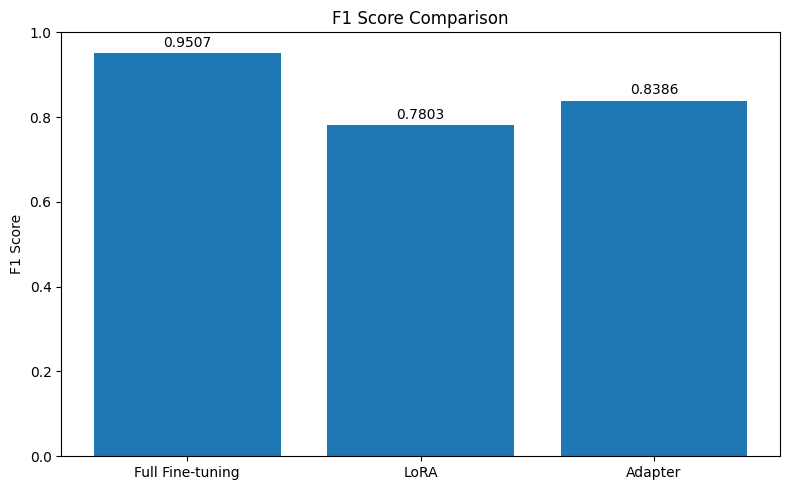

In [1]:
# نمودار مقایسه F1 سه روش

import matplotlib.pyplot as plt

methods = [
    "Full Fine-tuning",
    "LoRA",
    "Adapter"
]

f1_scores = [
    0.9507,
    0.7803,
    0.8386
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    f1_scores
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

# نمایش مقدار روی ستون‌ها
for bar, score in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.015,
        f"{score:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## ۹. جمع‌بندی

در این پروژه سه روش آموزش مدل XLM-RoBERTa برای تشخیص موجودیت‌های نامدار فارسی مقایسه شدند.

نتایج روی مجموعه test:

- Full Fine-tuning با F1 برابر `0.9507` بهترین عملکرد را داشت.
- Bottleneck Adapter با F1 برابر `0.8386` بهترین روش کم‌پارامتر بود.
- LoRA با F1 برابر `0.7803` کمترین تعداد پارامتر قابل‌آموزش را داشت.

Full Fine-tuning دقت بیشتری ارائه کرد، اما تمام پارامترهای مدل را آموزش داد. در مقابل، Adapter فقط حدود `0.6243%` از پارامترها را آموزش داد و نسبت به LoRA نتیجه بهتری به دست آورد.

بنابراین در این آزمایش، Bottleneck Adapter تعادل مناسب‌تری میان کاهش هزینه آموزش و حفظ کیفیت مدل ایجاد کرد.